<a href="https://colab.research.google.com/github/faheema2006/MLOPS/blob/main/SkillSync(K_means).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
%matplotlib inline

In [3]:
from google.colab import files
uploaded=files.upload()

Saving clean_resume_dataset.csv to clean_resume_dataset.csv


In [4]:
dataset=pd.read_csv('/content/clean_resume_dataset.csv')
print(dataset.head())

    ResumeID        Category              Name              Email  \
0  REAL_0001  Java Developer      Chad Griffin  contact@email.com   
1  REAL_0002  Java Developer    Melinda Thomas  contact@email.com   
2  REAL_0003  Java Developer  Shannon Mccarthy  contact@email.com   
3  REAL_0004  Java Developer  Christine Kelley  contact@email.com   
4  REAL_0005  Java Developer        Karen Holt  contact@email.com   

                                               Phone     Location  \
0  94105 555 4321000          10                 ...  City, State   
1  17994568777  2017 2018 20152016       3       ...  City, State   
2  9  555 4321000      94105   8                 ...  City, State   
3  9  555 4321000      94105   5                 ...  City, State   
4  100   10   4321000                            ...  City, State   

                                             Summary                   Skills  \
0  jessica claire montgomery street san francisco...  Python, SQL, Git, Linux   
1  jared

In [6]:
dataset['Resume_Length'] = dataset['Text'].apply(len)
dataset['Skill_Count'] = dataset['Text'].apply(lambda x: len(str(x).split()))

Text(0, 0.5, 'Skill Count')

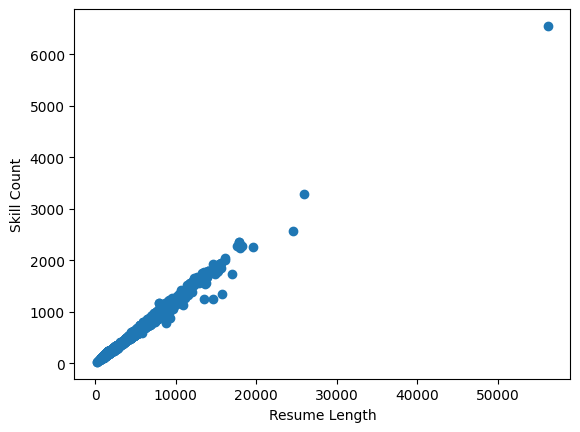

In [7]:
plt.scatter(dataset.Resume_Length,dataset.Skill_Count)
plt.xlabel('Resume Length')
plt.ylabel('Skill Count')

In [8]:
km = KMeans(n_clusters=3)

In [9]:
y_predicted = km.fit_predict(dataset[['Resume_Length', 'Skill_Count']])

In [10]:
y_predicted

array([0, 0, 2, ..., 0, 0, 0], dtype=int32)

In [11]:
dataset['cluster'] = y_predicted
dataset.head()

,ResumeID,Category,Name,Email,Phone,Location,Summary,Skills,Experience,Education,Text,Source,Resume_Length,Skill_Count,cluster
0,REAL_0001,Java Developer,Chad Griffin,contact@email.com,94105 555 4321000 10 ...,"City, State",jessica claire montgomery street san francisco...,"Python, SQL, Git, Linux",jessica claire montgomery street san francisco...,Computer Science degree,jessica claire montgomery street san francisco...,ResumeAtlas,1589,204,0
1,REAL_0002,Java Developer,Melinda Thomas,contact@email.com,17994568777 2017 2018 20152016 3 ...,"City, State",jared arthur maica java developer 17994568777 ...,"Python, SQL, Git, Linux",jared arthur maica java developer 17994568777 ...,Computer Science degree,jared arthur maica java developer 17994568777 ...,ResumeAtlas,1727,212,0
2,REAL_0003,Java Developer,Shannon Mccarthy,contact@email.com,9 555 4321000 94105 8 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas,5608,722,2
3,REAL_0004,Java Developer,Christine Kelley,contact@email.com,9 555 4321000 94105 5 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas,12888,1665,1
4,REAL_0005,Java Developer,Karen Holt,contact@email.com,100 10 4321000 ...,"City, State",jessica claire 100 montgomery st 10th floor xx...,"Python, SQL, Git, Linux",jessica claire 100 montgomery st 10th floor xx...,Computer Science degree,jessica claire 100 montgomery st 10th floor xx...,ResumeAtlas,4237,497,2


In [12]:
km.cluster_centers_

array([[ 1639.0802603 ,   213.35314534],
       [11905.6031746 ,  1464.29100529],
       [ 5697.94333996,   690.47514911]])

In [13]:
df1 = dataset[dataset.cluster == 0]
df2 = dataset[dataset.cluster == 1]
df3 = dataset[dataset.cluster == 2]

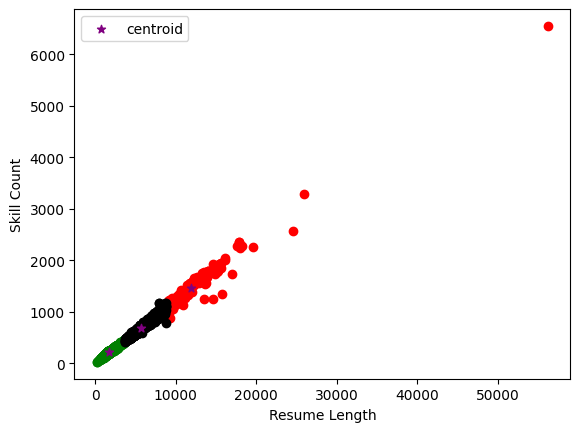

In [14]:
plt.scatter(df1.Resume_Length,df1.Skill_Count,color='green')
plt.scatter(df2.Resume_Length,df2.Skill_Count,color='red')
plt.scatter(df3.Resume_Length,df3.Skill_Count,color='black')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.xlabel('Resume Length')
plt.ylabel('Skill Count')
plt.legend()

In [15]:
scaler = MinMaxScaler()

In [16]:
scaler.fit(dataset[['Resume_Length']])
dataset['Resume_Length'] = scaler.transform(dataset[['Resume_Length']])

In [17]:
scaler.fit(dataset[['Skill_Count']])
dataset['Skill_Count'] = scaler.transform(dataset[['Skill_Count']])

In [18]:
dataset.head()

,ResumeID,Category,Name,Email,Phone,Location,Summary,Skills,Experience,Education,Text,Source,Resume_Length,Skill_Count,cluster
0,REAL_0001,Java Developer,Chad Griffin,contact@email.com,94105 555 4321000 10 ...,"City, State",jessica claire montgomery street san francisco...,"Python, SQL, Git, Linux",jessica claire montgomery street san francisco...,Computer Science degree,jessica claire montgomery street san francisco...,ResumeAtlas,0.024762,0.026969,0
1,REAL_0002,Java Developer,Melinda Thomas,contact@email.com,17994568777 2017 2018 20152016 3 ...,"City, State",jared arthur maica java developer 17994568777 ...,"Python, SQL, Git, Linux",jared arthur maica java developer 17994568777 ...,Computer Science degree,jared arthur maica java developer 17994568777 ...,ResumeAtlas,0.027225,0.028195,0
2,REAL_0003,Java Developer,Shannon Mccarthy,contact@email.com,9 555 4321000 94105 8 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas,0.096512,0.106344,2
3,REAL_0004,Java Developer,Christine Kelley,contact@email.com,9 555 4321000 94105 5 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas,0.226479,0.250843,1
4,REAL_0005,Java Developer,Karen Holt,contact@email.com,100 10 4321000 ...,"City, State",jessica claire 100 montgomery st 10th floor xx...,"Python, SQL, Git, Linux",jessica claire 100 montgomery st 10th floor xx...,Computer Science degree,jessica claire 100 montgomery st 10th floor xx...,ResumeAtlas,0.072036,0.071866,2


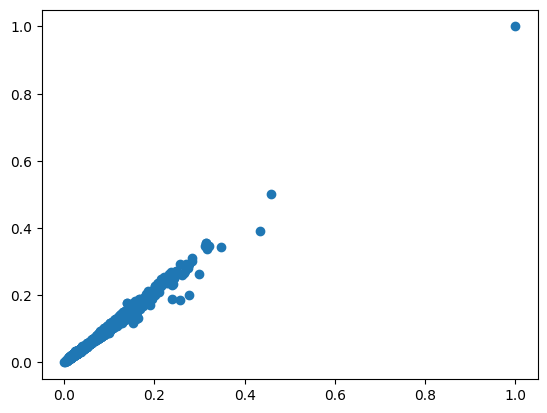

In [19]:
plt.scatter(dataset.Resume_Length,dataset.Skill_Count)

In [20]:
km = KMeans(n_clusters=3)

In [21]:
y_predicted = km.fit_predict(dataset[['Resume_Length', 'Skill_Count']])

In [22]:
y_predicted

array([0, 0, 2, ..., 0, 0, 0], dtype=int32)

In [23]:
dataset['cluster'] = y_predicted
dataset.head()

,ResumeID,Category,Name,Email,Phone,Location,Summary,Skills,Experience,Education,Text,Source,Resume_Length,Skill_Count,cluster
0,REAL_0001,Java Developer,Chad Griffin,contact@email.com,94105 555 4321000 10 ...,"City, State",jessica claire montgomery street san francisco...,"Python, SQL, Git, Linux",jessica claire montgomery street san francisco...,Computer Science degree,jessica claire montgomery street san francisco...,ResumeAtlas,0.024762,0.026969,0
1,REAL_0002,Java Developer,Melinda Thomas,contact@email.com,17994568777 2017 2018 20152016 3 ...,"City, State",jared arthur maica java developer 17994568777 ...,"Python, SQL, Git, Linux",jared arthur maica java developer 17994568777 ...,Computer Science degree,jared arthur maica java developer 17994568777 ...,ResumeAtlas,0.027225,0.028195,0
2,REAL_0003,Java Developer,Shannon Mccarthy,contact@email.com,9 555 4321000 94105 8 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas,0.096512,0.106344,2
3,REAL_0004,Java Developer,Christine Kelley,contact@email.com,9 555 4321000 94105 5 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas,0.226479,0.250843,1
4,REAL_0005,Java Developer,Karen Holt,contact@email.com,100 10 4321000 ...,"City, State",jessica claire 100 montgomery st 10th floor xx...,"Python, SQL, Git, Linux",jessica claire 100 montgomery st 10th floor xx...,Computer Science degree,jessica claire 100 montgomery st 10th floor xx...,ResumeAtlas,0.072036,0.071866,2


In [24]:
km.cluster_centers_

array([[0.02565834, 0.02838896],
       [0.20292167, 0.21539752],
       [0.09713911, 0.10013325]])

In [25]:
df1 = dataset[dataset.cluster == 0]
df2 = dataset[dataset.cluster == 1]
df3 = dataset[dataset.cluster == 2]

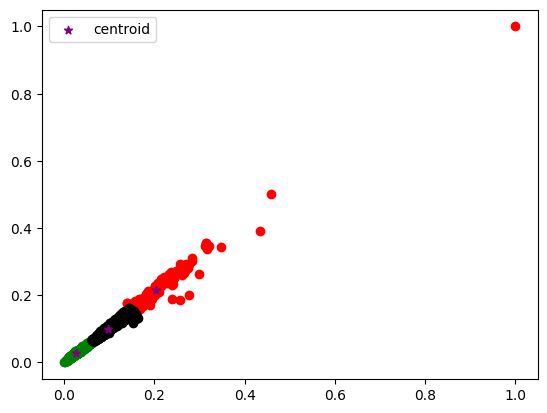

In [26]:
plt.scatter(df1.Resume_Length,df1.Skill_Count,color='green')
plt.scatter(df2.Resume_Length,df2.Skill_Count,color='red')
plt.scatter(df3.Resume_Length,df3.Skill_Count,color='black')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.legend()

In [27]:
sse = []
k_rng = range(1,10)

In [28]:
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(dataset[['Resume_Length', 'Skill_Count']])
    sse.append(km.inertia_)

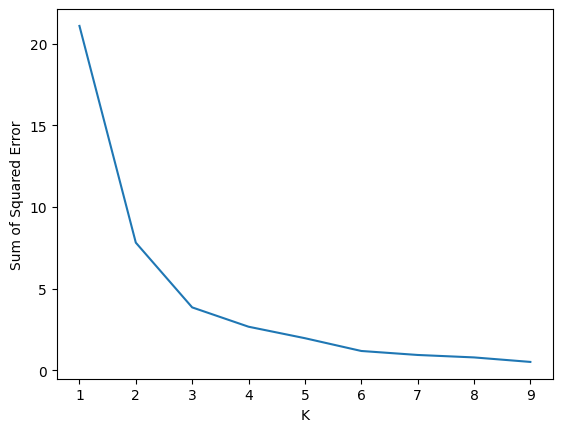

In [29]:
plt.xlabel('K')
plt.ylabel('Sum of Squared Error')
plt.plot(k_rng, sse)

In [30]:
from sklearn.metrics import silhouette_score
score = silhouette_score(dataset[['Resume_Length', 'Skill_Count']],y_predicted)
print("Silhouette Score:", score)

Silhouette Score: 0.7250970674285798
